# Evaluation & interpretation
Consumes (yum ;p) the outputs of:
- **notebook 3**: Logreg, MLP, SAE, XGBoost predictions in `results/predictions.pkl`
- **notebook 4**: Multitask model predictions in `results/predictions.pkl` and `results/multitask_predictions.pkl`

Produces hella figures and tables:
1. **Test-set metrics**: AUROC / AUPRC / F1 across all five models
2. **ROC & PR curves**: single panel comparing every model
3. **Stratified performance**: best classifier broken down by cell-type cluster and by tissue
4. **Clone-size calibration**: predicted P(expanded) vs true clone size
5. **Latent space UMAPs**: SAE and multitask encoders side by side
6. **Multitask auxiliary tasks**: per-class cell-state accuracy & clone-bin confusion matrix
7. **Gene importance**: standardized logreg, input x gradient for the neural nets, gain-based for XGBoost, then a cross-model consensus
8. **T cell bio overlap**: top consensus genes vs known T cell programs

In [1]:
# colab setup
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
PROJECT_DIR_DRIVE = '/content/drive/MyDrive/final_project'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_DIR = PROJECT_DIR_DRIVE
    subprocess.run(['pip', 'install', '-q', 'scanpy', 'umap-learn', 'xgboost'], check=True)
else:
    PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
print('PROJECT_DIR =', PROJECT_DIR)

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/final_project


### Imports, configs, and data

In [2]:
import pickle
from pathlib import Path
import anndata as ad
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, confusion_matrix,
)

from src import data as D
from src import train as T
from src import evaluate as E
from src.models import MLPClassifier, SupervisedAutoencoder, MultiTaskModel

sns.set_context('talk')
sns.set_style('whitegrid')
FIG_DIR = Path(RESULTS_DIR) / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# bundle with all 4 single task models + multitask
with open(Path(RESULTS_DIR) / 'predictions.pkl', 'rb') as f:
    preds = pickle.load(f)
with open(Path(RESULTS_DIR) / 'multitask_predictions.pkl', 'rb') as f:
    mt_bundle = pickle.load(f)

gene_names = preds['gene_names']
y_test = preds['y_test']
y_val  = preds['y_val']

adata    = ad.read_h5ad(Path(DATA_DIR) / 'processed.h5ad')
train_ad = adata[adata.obs['split'] == 'train']
test_ad  = adata[adata.obs['split'] == 'test']
X_train  = D.to_matrix(train_ad)
X_test   = D.to_matrix(test_ad)
print('test cells:', X_test.shape[0], ' genes:', X_test.shape[1])
print('models in preds:', list(preds.keys()))
print('multitask config:', mt_bundle['config'])

test cells: 16131  genes: 2000
models in preds: ['gene_names', 'y_val', 'y_test', 'logreg', 'mlp', 'sae', 'xgb', 'multitask']
multitask config: {'hidden_dims': (512, 128), 'latent_dim': 64, 'dropout': 0.2, 'w_expanded': 1.0, 'w_clone': 0.3, 'w_ident': 1.0}


In [4]:
# architectures
_sae_cfg = preds.get('sae', {}).get('config', {})
_mlp_cfg = preds.get('mlp', {}).get('config', {})
_mt_cfg  = mt_bundle['config']

BEST_MLP_HIDDEN  = tuple(_mlp_cfg.get('hidden_dims', (256,)))
BEST_MLP_DROPOUT = float(_mlp_cfg.get('dropout', 0.1))
BEST_SAE_HIDDEN  = tuple(_sae_cfg.get('hidden_dims', (512, 128)))
BEST_SAE_LATENT  = int(_sae_cfg.get('latent_dim', 64))
BEST_SAE_DROPOUT = float(_sae_cfg.get('dropout', 0.2))
MT_HIDDEN  = tuple(_mt_cfg['hidden_dims'])
MT_LATENT  = int(_mt_cfg['latent_dim'])
MT_DROPOUT = float(_mt_cfg['dropout'])
print(f'MLP: hidden={BEST_MLP_HIDDEN}, dropout={BEST_MLP_DROPOUT}')
print(f'SAE: hidden={BEST_SAE_HIDDEN}, latent={BEST_SAE_LATENT}, dropout={BEST_SAE_DROPOUT}')
print(f'MT : hidden={MT_HIDDEN}, latent={MT_LATENT}, dropout={MT_DROPOUT}')

MLP: hidden=(256,), dropout=0.1
SAE: hidden=(512, 128), latent=64, dropout=0.2
MT : hidden=(512, 128), latent=64, dropout=0.2


## Eval 1: Model comparison

Test-set AUROC / AUPRC / F1 for all five models, joint ROC and PR plots.

The selected metric (step 3, step 4 below) is the best test-set AUROC.

In [5]:
MODELS = ['logreg', 'mlp', 'sae', 'xgb', 'multitask']
PRETTY = {'logreg': 'Logistic Regression', 'mlp': 'MLP',
          'sae': 'Supervised AE', 'xgb': 'XGBoost', 'multitask': 'Multitask'}

rows = []
for name in MODELS:
    m = E.classification_metrics(y_test, preds[name]['test'])
    m['model'] = PRETTY[name]
    rows.append(m)
metrics_df = (pd.DataFrame(rows).set_index('model')
                [['auroc', 'auprc', 'f1', 'positive_rate']])
metrics_df.to_csv(Path(RESULTS_DIR) / 'test_metrics.csv')

BEST_MODEL = metrics_df['auroc'].idxmax()
BEST_KEY   = {v: k for k, v in PRETTY.items()}[BEST_MODEL]
print(f'best classifier by test AUROC: {BEST_MODEL}  (key={BEST_KEY})')
metrics_df

best classifier by test AUROC: XGBoost  (key=xgb)


,auroc,auprc,f1,positive_rate
model,,,,
Logistic Regression,0.788197,0.751018,0.725228,0.490608
MLP,0.775779,0.738264,0.685809,0.490608
Supervised AE,0.771420,0.739853,0.705787,0.490608
XGBoost,0.810813,0.765829,0.749984,0.490608
Multitask,0.775030,0.731755,0.706403,0.490608


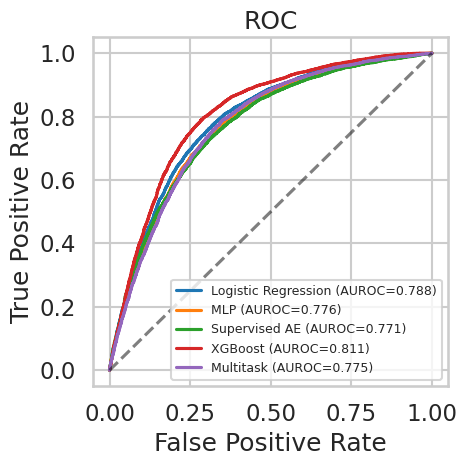

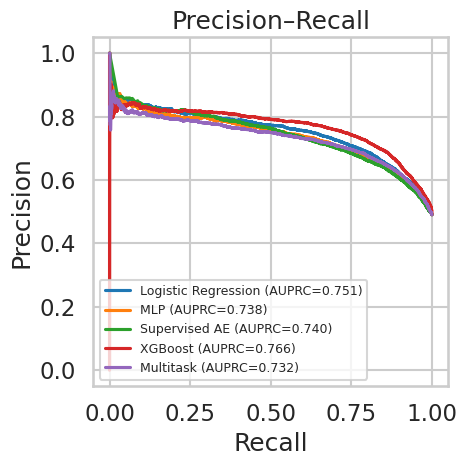

In [6]:
curves = {PRETTY[name]: (y_test, preds[name]['test']) for name in MODELS}
E.plot_roc(curves, out=FIG_DIR / 'roc_test.png')
E.plot_pr(curves,  out=FIG_DIR / 'pr_test.png')
plt.show()

## Eval 2: Clone size calibration

Does predicted P(expanded) track the true clone-size magnitude?

A clean monotonic relationship (singleton -> small -> medium -> large) shows the
model captures expansion intensity (not just binary label)

                   mean    median  count
clone_bin                               
singleton      0.342245  0.265371   8217
small (2-3)    0.520679  0.537818   2240
medium (4-10)  0.650276  0.706037   1903
large (11+)    0.707416  0.744625   3771


/tmp/ipykernel_14276/4033950477.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=obs, x='clone_bin', y='prob', order=labels,


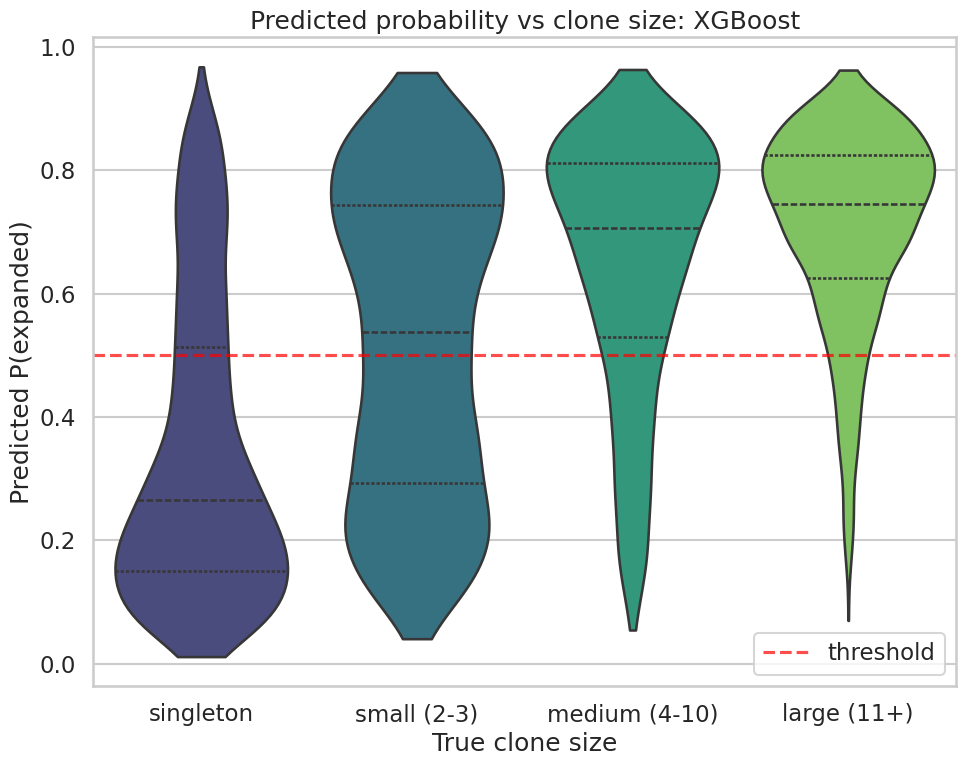

In [22]:
obs = test_ad.obs.copy()
obs['prob'] = preds[BEST_KEY]['test']

bins = [0, 1, 3, 10, np.inf]
labels = ['singleton', 'small (2-3)', 'medium (4-10)', 'large (11+)']
obs['clone_bin'] = pd.cut(obs['clone_size'], bins=bins, labels=labels)

calib = obs.groupby('clone_bin', observed=True)['prob'].agg(['mean', 'median', 'count'])
calib.to_csv(Path(RESULTS_DIR) / 'clone_size_calibration.csv')
print(calib)

fig, ax = plt.subplots(figsize=(10, 8))
sns.violinplot(data=obs, x='clone_bin', y='prob', order=labels,
               cut=0, inner='quartile', palette='viridis', ax=ax)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='threshold')
ax.set_xlabel('True clone size')
ax.set_ylabel('Predicted P(expanded)')
ax.set_title(f'Predicted probability vs clone size: {BEST_MODEL}')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'prob_by_clone_size.png', dpi=200, bbox_inches='tight')
plt.show()

## Eval 3: Stratified performance

Per-cell-type and per-tissue AUROC + AUPRC for the best classifier.

AUROC depends on the positive class fraction within each strata, so in CD8 effector clusters where most cells are already expanded, AUROC  drops but AUPRC stays high => AUPRC is the more useful metric

In [8]:
def stratified_metrics(obs, group_col, prob_col='prob', label_col='expanded', min_n=50):
    rows = []
    for v, g in obs.groupby(group_col, observed=True):
        if g[label_col].nunique() < 2 or len(g) < min_n:
            continue
        rows.append({
            group_col: v,
            'n': len(g),
            'pos_rate': g[label_col].mean(),
            'auroc': roc_auc_score(g[label_col], g[prob_col]),
            'auprc': average_precision_score(g[label_col], g[prob_col]),
        })
    return pd.DataFrame(rows).sort_values('pos_rate')

ident_perf = stratified_metrics(obs, 'ident')
src_perf   = stratified_metrics(obs, 'source')
ident_perf.to_csv(Path(RESULTS_DIR) / 'stratified_by_ident.csv', index=False)
src_perf.to_csv(Path(RESULTS_DIR) / 'stratified_by_source.csv', index=False)
ident_perf

,ident,n,pos_rate,auroc,auprc
3,4.3-TCF7,1812,0.092163,0.696282,0.186332
2,4.2-RPL32,716,0.219274,0.804348,0.577584
4,4.4-FOS,1881,0.232323,0.719287,0.474095
6,4.6a-Treg,1486,0.296770,0.625675,0.414128
5,4.5-IL6ST,705,0.321986,0.716808,0.534553
1,4.1-Trm,929,0.337998,0.644042,0.456389
13,8.4-Chrom,109,0.422018,0.638371,0.586633
7,4.6b-Treg,388,0.430412,0.641423,0.559891
15,8.6-KLRB1,154,0.474026,0.684932,0.595758
0,3.1-MT,696,0.622126,0.794870,0.824811


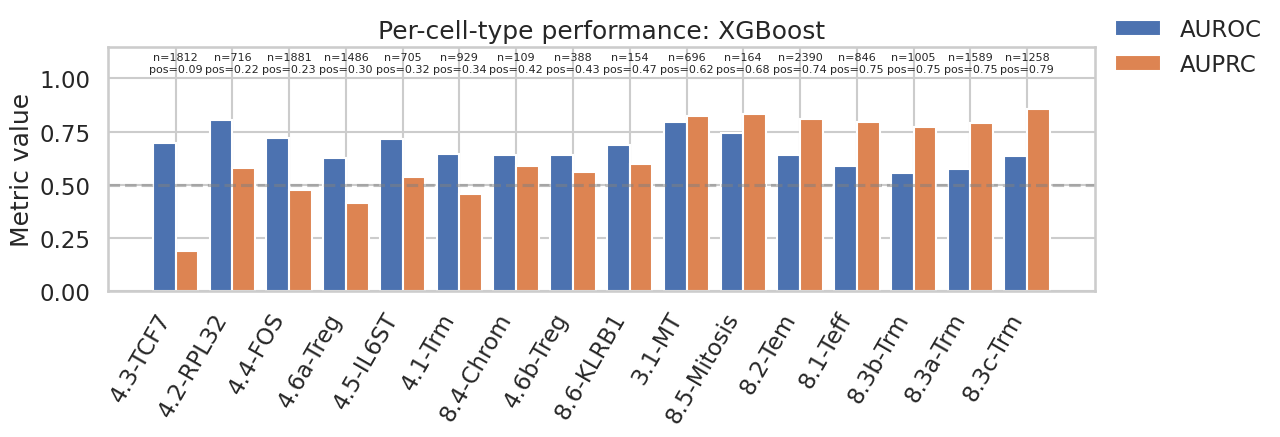

In [35]:
# per-cell-type bar chart
df = ident_perf
x = np.arange(len(df))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.20, df['auroc'], width=0.4, label='AUROC', color='#4c72b0')
ax.bar(x + 0.20, df['auprc'], width=0.4, label='AUPRC', color='#dd8452')
for i, (n, pos) in enumerate(zip(df['n'], df['pos_rate'])):
    ax.text(i, 1.02, f'n={n}\npos={pos:.2f}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df['ident'], rotation=60, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Metric value')
ax.set_title(f'Per-cell-type performance: {BEST_MODEL}')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.2), frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'stratified_by_ident.png', dpi=200, bbox_inches='tight')
plt.show()

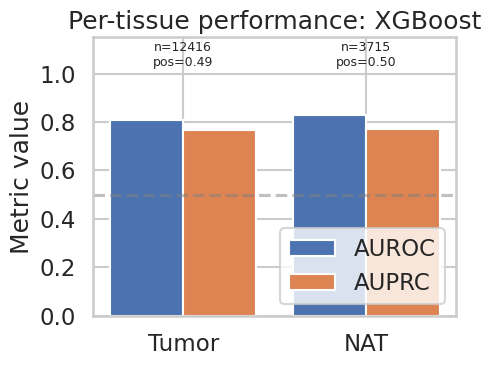

,source,n,pos_rate,auroc,auprc
1,Tumor,12416,0.487838,0.807536,0.766240
0,NAT,3715,0.499865,0.829989,0.772269


In [36]:
# per-tissue bar chart
df = src_perf
x = np.arange(len(df))
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - 0.20, df['auroc'], width=0.4, label='AUROC', color='#4c72b0')
ax.bar(x + 0.20, df['auprc'], width=0.4, label='AUPRC', color='#dd8452')
for i, (n, pos) in enumerate(zip(df['n'], df['pos_rate'])):
    ax.text(i, 1.02, f'n={n}\npos={pos:.2f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(df['source'])
ax.set_ylim(0, 1.15); ax.set_ylabel('Metric value')
ax.set_title(f'Per-tissue performance: {BEST_MODEL}')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'stratified_by_source.png', dpi=200, bbox_inches='tight')
plt.show()
src_perf

## Eval 4: Latent space UMAPs

Project test cells through the SAE encoder and the multitask encoder, then run UMAP. Color by expansion, cell type, tissue, and patient.

The multitask encoder is forced to organize cells for three supervised tasks at once; should be cleaner cell-type structure than the SAE

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


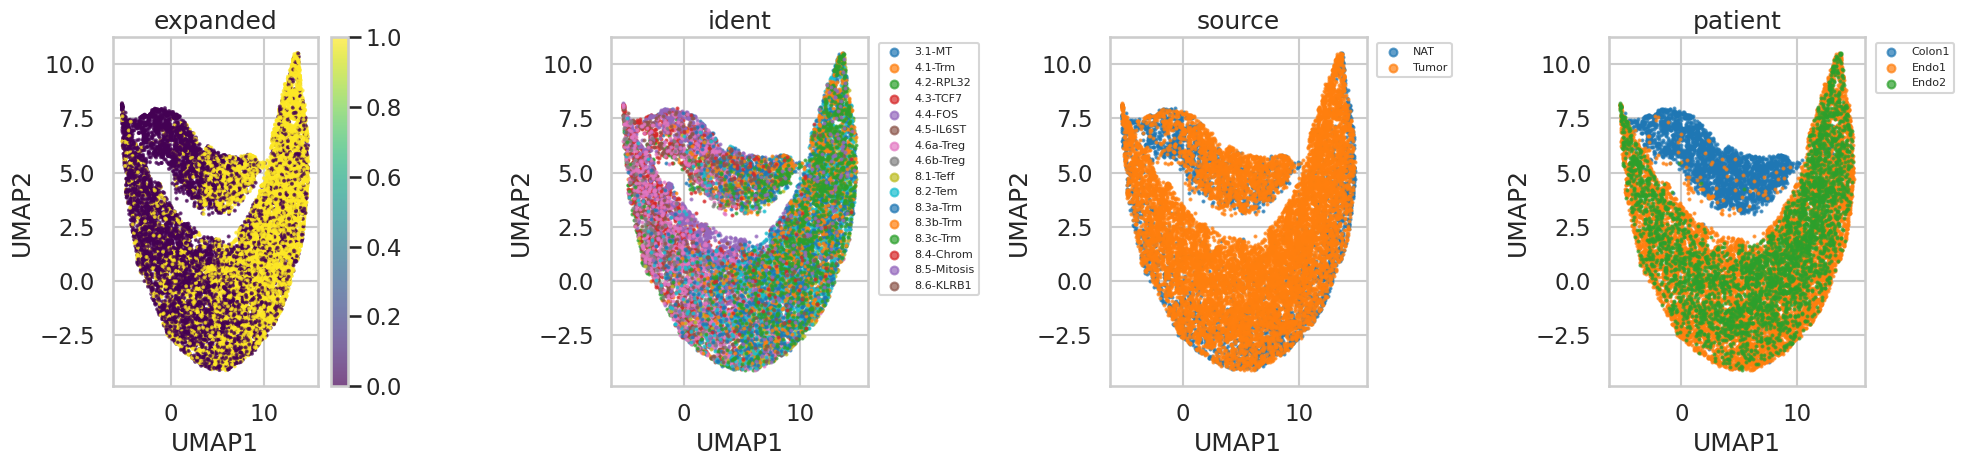

In [11]:
# SAE encoder
sae = SupervisedAutoencoder(
    in_features=X_test.shape[1],
    hidden_dims=BEST_SAE_HIDDEN, latent_dim=BEST_SAE_LATENT, dropout=BEST_SAE_DROPOUT,
)
sae.load_state_dict(
    torch.load(Path(RESULTS_DIR) / 'models' / 'sae.pt', map_location='cpu')
)
Z_sae = T.encode_latents(sae, X_test)

umap_obs = test_ad.obs.copy()
umap_obs['expanded'] = umap_obs['expanded'].astype(int)
candidate_cols = ['expanded', 'ident', 'source', 'patient']
color_cols = [c for c in candidate_cols if c in umap_obs.columns]

E.plot_latent_umap(Z_sae, umap_obs, color_cols,
                    out=FIG_DIR / 'sae_latent_umap.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


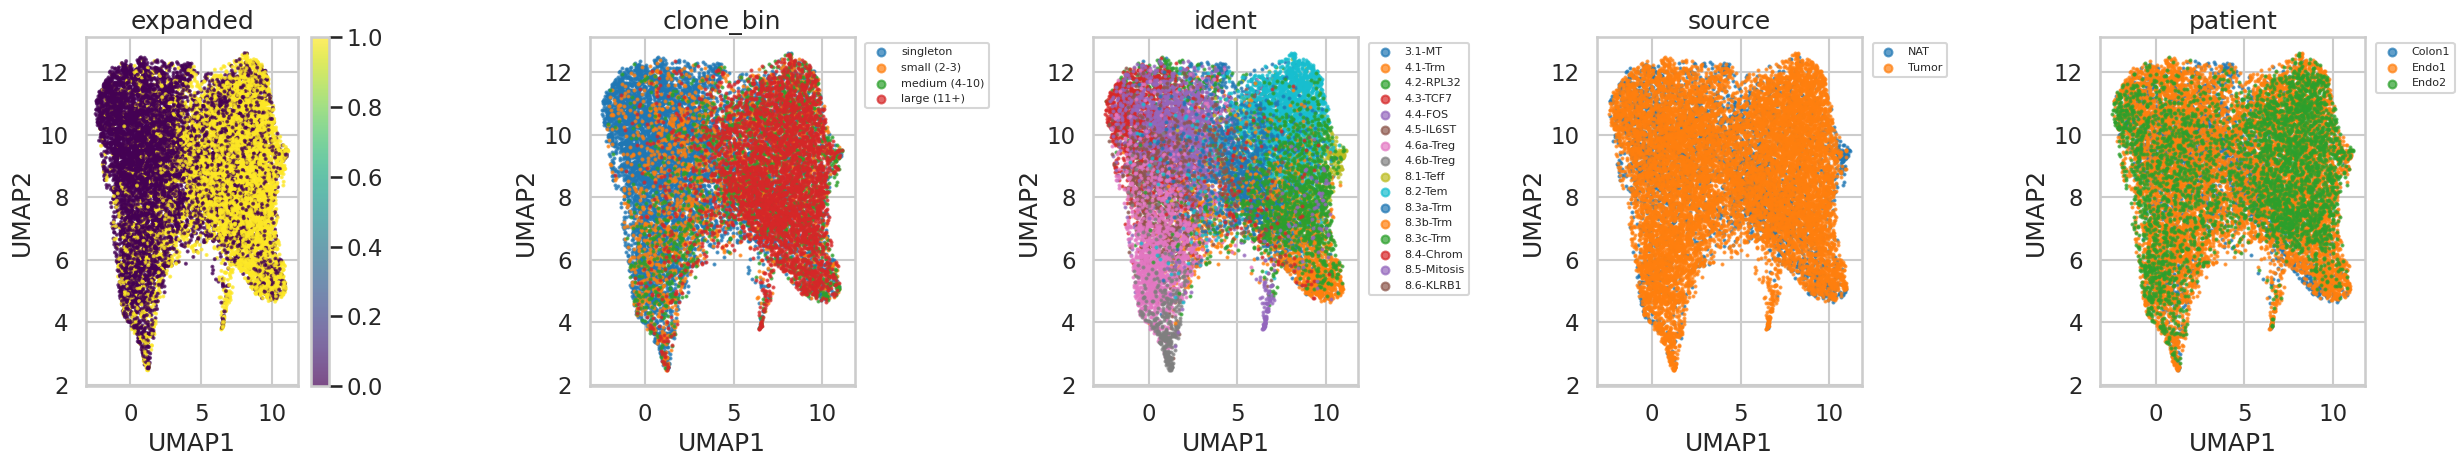

In [12]:
# multitask encoder (use the saved latent matrix from bundle)
Z_mt = mt_bundle['test']['z']

mt_obs = umap_obs.copy()
mt_obs['clone_bin'] = pd.cut(mt_obs['clone_size'], bins=bins, labels=labels)
mt_color_cols = [c for c in ['expanded', 'clone_bin', 'ident', 'source', 'patient']
                  if c in mt_obs.columns]

E.plot_latent_umap(Z_mt, mt_obs, mt_color_cols,
                    out=FIG_DIR / 'multitask_latent_umap.png')
plt.show()

## Eval 5: Multitask auxiliary tasks

Performance on the two auxiliary heads.

Show whether the encoder actually learned biologically meaningful structure beyond the expansion label (vs just improved classification AUROC)

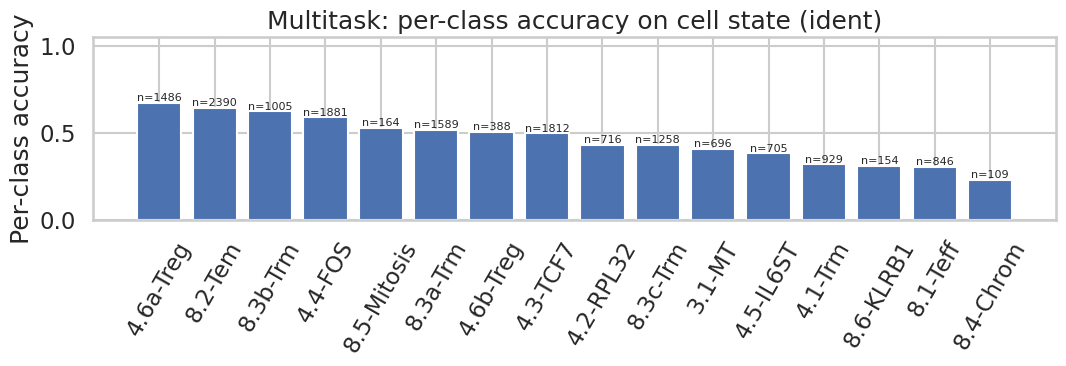

,ident,n,accuracy
6,4.6a-Treg,1486,0.671602
9,8.2-Tem,2390,0.646444
11,8.3b-Trm,1005,0.623881
4,4.4-FOS,1881,0.590112
14,8.5-Mitosis,164,0.530488
10,8.3a-Trm,1589,0.516677
7,4.6b-Treg,388,0.505155
3,4.3-TCF7,1812,0.497792
2,4.2-RPL32,716,0.430168
12,8.3c-Trm,1258,0.430048


In [37]:
# per-class accuracy on the cell-state (ident) head
ident_label_list = mt_bundle['ident_label_list']
y_ident_test = mt_bundle['Y_test']['ident']
yhat_ident   = mt_bundle['test']['p_ident'].argmax(1)

rows = []
for i, label in enumerate(ident_label_list):
    mask = y_ident_test == i
    if mask.sum() < 30:
        continue
    rows.append({'ident': label, 'n': int(mask.sum()),
                 'accuracy': float((yhat_ident[mask] == i).mean())})
pc_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False)
pc_df.to_csv(Path(RESULTS_DIR) / 'multitask_ident_per_class_acc.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(pc_df['ident'], pc_df['accuracy'], color='#4c72b0')
ax.set_ylabel('Per-class accuracy')
ax.set_title('Multitask: per-class accuracy on cell state (ident)')
ax.tick_params(axis='x', rotation=60)
for i, (n, a) in enumerate(zip(pc_df['n'], pc_df['accuracy'])):
    ax.text(i, a + 0.01, f'n={n}', ha='center', fontsize=8)
ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / 'multitask_ident_acc.png', dpi=200, bbox_inches='tight')
plt.show()
pc_df.head(20)

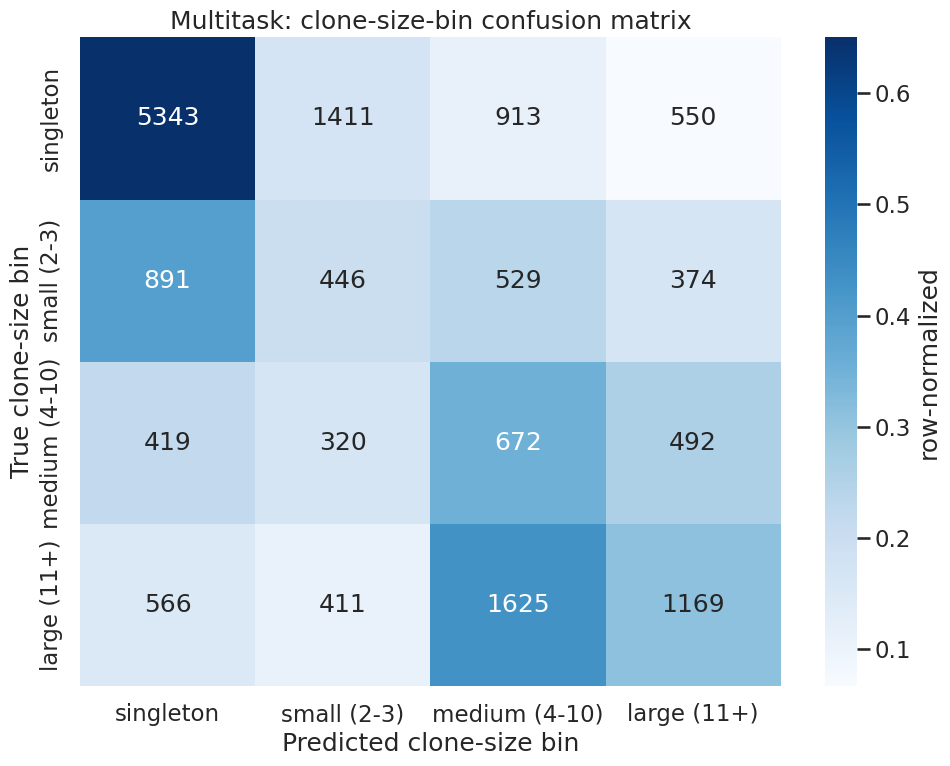

overall clone_bin accuracy: 0.473


In [39]:
# confusion matrix on the clone-size-bin head
clone_label_list = mt_bundle['clone_label_list']
y_clone_test = mt_bundle['Y_test']['clone_bin']
yhat_clone   = mt_bundle['test']['p_clone_bin'].argmax(1)
cm = confusion_matrix(y_clone_test, yhat_clone,
                       labels=list(range(len(clone_label_list))))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=clone_label_list, yticklabels=clone_label_list,
            ax=ax, cbar_kws={'label': 'row-normalized'})
ax.set_xlabel('Predicted clone-size bin')
ax.set_ylabel('True clone-size bin')
ax.set_title('Multitask: clone-size-bin confusion matrix')
fig.tight_layout()
fig.savefig(FIG_DIR / 'multitask_clone_bin_cm.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'overall clone_bin accuracy: {np.diag(cm).sum() / cm.sum():.3f}')

## Eval 6: Gene importance w/ corrected attribution

Raw LogReg coefficients and `mean(|gradient|)` overweight sparsely expressed pseudogenes / ncRNAs because they multiply a small data footprint by a large per-feature number.

So, instead use:
- **LogReg**: standardized effect β · σ (coefficient x training-set SD)
- **MLP / SAE / Multitask**: *input x gradient* attribution on the expansion logit.
- **XGBoost**: gain-based feature importance from the library (already correct lol)

In [15]:
#logreg: standardized effect
gene_std = X_train.std(axis=0)
lr_effect = preds['logreg']['coef'] * gene_std
top_lr = (pd.DataFrame({'gene': gene_names, 'effect': lr_effect,
                       'coef': preds['logreg']['coef']})
          .assign(abs_effect=lambda d: d['effect'].abs())
          .sort_values('abs_effect', ascending=False)
          .drop(columns='abs_effect'))
top_lr['direction'] = np.where(top_lr['effect'] > 0,
                                'up (expanded)', 'down (singleton)')
top_lr.head(40).to_csv(Path(RESULTS_DIR) / 'top_genes_logreg_standardized.csv',
                       index=False)
top_lr.head(15)

,gene,effect,coef,direction
515,NKG7,0.367002,0.227824,up (expanded)
1667,SELL,-0.213917,-0.261522,down (singleton)
755,FGFBP2,0.211031,0.338719,up (expanded)
375,EEF1A1,-0.208982,-0.296670,down (singleton)
1101,CCR7,-0.181974,-0.285060,down (singleton)
29,CST7,0.178079,0.140921,up (expanded)
541,GZMH,0.160162,0.136310,up (expanded)
737,PASK,-0.154465,-0.276895,down (singleton)
675,DUSP2,0.139030,0.091853,up (expanded)
1085,CCL4,0.138712,0.080603,up (expanded)


In [16]:
# input × gradient for the three neural models
def input_x_gradient(model, X, gene_names, batch_size=512, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval().to(device)
    sums = np.zeros(X.shape[1], dtype=np.float64)
    count = 0
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size].astype(np.float32))
        xb = xb.to(device).requires_grad_(True)
        out = model(xb)
        if isinstance(out, dict):
            logit = out['expanded']
        elif isinstance(out, tuple):
            logit = out[1]
        else:
            logit = out
        logit.sum().backward()
        sums += (xb.detach() * xb.grad.detach()).abs().sum(axis=0).cpu().numpy()
        count += xb.size(0)
    return (pd.DataFrame({'gene': gene_names, 'attribution': sums / count})
              .sort_values('attribution', ascending=False)
              .reset_index(drop=True))

mlp = MLPClassifier(in_features=X_test.shape[1],
                    hidden_dims=BEST_MLP_HIDDEN, dropout=BEST_MLP_DROPOUT)
mlp.load_state_dict(
    torch.load(Path(RESULTS_DIR) / 'models' / 'mlp.pt', map_location='cpu')
)

mt_model = MultiTaskModel(
    in_features=X_test.shape[1],
    n_clone_bins=len(mt_bundle['clone_label_list']),
    n_idents=len(mt_bundle['ident_label_list']),
    hidden_dims=MT_HIDDEN, latent_dim=MT_LATENT, dropout=MT_DROPOUT,
)
mt_model.load_state_dict(
    torch.load(Path(RESULTS_DIR) / 'models' / 'multitask.pt', map_location='cpu')
)

attr_mlp = input_x_gradient(mlp,      X_test, gene_names)
attr_sae = input_x_gradient(sae,      X_test, gene_names)
attr_mt  = input_x_gradient(mt_model, X_test, gene_names)
attr_mlp.to_csv(Path(RESULTS_DIR) / 'gene_attribution_mlp.csv', index=False)
attr_sae.to_csv(Path(RESULTS_DIR) / 'gene_attribution_sae.csv', index=False)
attr_mt.to_csv(Path(RESULTS_DIR) / 'gene_attribution_multitask.csv', index=False)
attr_mlp.head(15)

,gene,attribution
0,EEF1A1,1.097672
1,FXYD5,0.348618
2,ACTB,0.328365
3,RNR2,0.311318
4,JUN,0.304624
5,COX1,0.265230
6,DNAJB1,0.214234
7,NKG7,0.208177
8,FTH1,0.198800
9,DUSP2,0.190727


In [17]:
# xgb: gain-based importance
xgb_imp = (pd.DataFrame({'gene': gene_names,
                         'importance': preds['xgb']['feature_importance']})
             .sort_values('importance', ascending=False)
             .reset_index(drop=True))
xgb_imp.to_csv(Path(RESULTS_DIR) / 'gene_importance_xgb.csv', index=False)
xgb_imp.head(15)

,gene,importance
0,NKG7,0.089185
1,EEF1A1,0.017778
2,GZMH,0.017651
3,CCL4,0.011454
4,SELL,0.011081
5,CCR7,0.008637
6,XCL1,0.008249
7,CXCR6,0.007850
8,PASK,0.006506
9,HOPX,0.006465


### Cross-model consensus

Rank each gene 1......N in each model, then average the ranks.

Top of the
consensus = genes that every model agrees matter for expansion.

In [18]:
lr_abs = pd.DataFrame({'gene': gene_names, 'lr': np.abs(lr_effect)})

cons = (lr_abs
        .merge(attr_mlp.rename(columns={'attribution': 'mlp'}), on='gene')
        .merge(attr_sae.rename(columns={'attribution': 'sae'}), on='gene')
        .merge(xgb_imp.rename(columns={'importance': 'xgb'}), on='gene')
        .merge(attr_mt.rename(columns={'attribution': 'multitask'}), on='gene'))

rank_cols = ['lr', 'mlp', 'sae', 'xgb', 'multitask']
for c in rank_cols:
    cons[f'{c}_rank'] = cons[c].rank(ascending=False)
cons['mean_rank'] = cons[[f'{c}_rank' for c in rank_cols]].mean(axis=1)
consensus = cons.sort_values('mean_rank').head(50)
consensus.to_csv(Path(RESULTS_DIR) / 'consensus_top_genes.csv', index=False)
consensus[['gene'] + [f'{c}_rank' for c in rank_cols] + ['mean_rank']].head(25)

,gene,lr_rank,mlp_rank,sae_rank,xgb_rank,multitask_rank,mean_rank
375,EEF1A1,4.0,1.0,1.0,2.0,1.0,1.8
515,NKG7,1.0,8.0,8.0,1.0,9.0,5.4
461,FXYD5,18.0,2.0,2.0,57.0,2.0,16.2
29,CST7,6.0,23.0,20.0,15.0,21.0,17.0
1085,CCL4,10.0,21.0,21.0,4.0,31.0,17.4
675,DUSP2,9.0,10.0,13.0,47.0,13.0,18.4
1917,DUSP1,11.0,11.0,12.0,50.0,11.0,19.0
1845,IL7R,13.0,17.0,26.0,31.0,24.0,22.2
1236,ACTB,25.0,3.0,3.0,80.0,3.0,22.8
1996,RNR2,26.0,4.0,4.0,84.0,5.0,24.6


## Eval 7: T cell programs

Known lists of canonical genes for the T cell programs most relevant to clonal expansion.

Reports how many of the top-50 consensus genes fall into each program.

#### The cytotoxic-effector and naïve/CM hits should dominate; the model independently rediscovers the Wu et al. 2020 conclusion that expanded TILs are CD8 effector / TRM-skewed!

In [40]:
PROGRAMS = {
    'Cytotoxic effector': ['NKG7', 'GZMB', 'GZMA', 'GZMH', 'GZMK', 'PRF1', 'GNLY',
                           'CCL4', 'CCL5', 'XCL1', 'XCL2', 'IFNG', 'TNF', 'HOPX'],
    'Tissue-resident memory': ['CXCR6', 'ITGAE', 'ZNF683', 'ITGA1', 'RGS1', 'DUSP6'],
    'Exhaustion / dysfunction': ['PDCD1', 'HAVCR2', 'LAG3', 'TIGIT', 'TOX', 'ENTPD1',
                                  'CTLA4', 'BATF', 'EOMES'],
    'Naive / central memory': ['CCR7', 'SELL', 'LEF1', 'TCF7', 'IL7R'],
    'Regulatory T': ['FOXP3', 'IL2RA', 'IKZF2', 'CTLA4', 'TIGIT'],
}
top50 = set(consensus.head(50)['gene'])
rows = []
for program, genes in PROGRAMS.items():
    hits = sorted(set(genes) & top50)
    rows.append({'program': program, 'n_in_panel': len(genes),
                 'n_hits_in_top50': len(hits), 'hits': ', '.join(hits)})
overlap_df = pd.DataFrame(rows)
overlap_df.to_csv(Path(RESULTS_DIR) / 'program_overlap.csv', index=False)
overlap_df

,program,n_in_panel,n_hits_in_top50,hits
0,Cytotoxic effector,14,9,"CCL4, GNLY, GZMB, GZMH, GZMK, HOPX, NKG7, XCL1..."
1,Tissue-resident memory,6,2,"RGS1, ZNF683"
2,Exhaustion / dysfunction,9,1,BATF
3,Naive / central memory,5,3,"CCR7, IL7R, SELL"
4,Regulatory T,5,0,


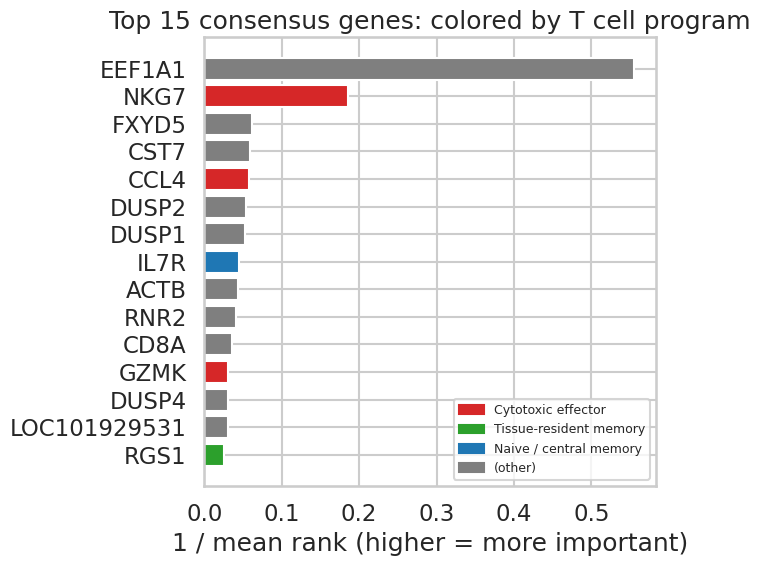

In [41]:
# top-15 consensus genes colored by program
GENE_TO_PROGRAM = {g: p for p, gs in PROGRAMS.items() for g in gs}
PROG_COLORS = {
    'Cytotoxic effector': '#d62728',
    'Tissue-resident memory': '#2ca02c',
    'Exhaustion / dysfunction': '#9467bd',
    'Naive / central memory': '#1f77b4',
    'Regulatory T': '#ff7f0e',
    '(other)': '#7f7f7f',
}
top15 = consensus.head(15).copy()
top15['program'] = top15['gene'].map(GENE_TO_PROGRAM).fillna('(other)')
top15['color'] = top15['program'].map(PROG_COLORS)
top15 = top15.iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15['gene'], 1 / top15['mean_rank'], color=top15['color'])
ax.set_xlabel('1 / mean rank (higher = more important)')
ax.set_title('Top 15 consensus genes: colored by T cell program')
from matplotlib.patches import Patch
handles = [Patch(color=c, label=p) for p, c in PROG_COLORS.items()
           if p in top15['program'].values]
ax.legend(handles=handles, loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'top15_consensus_genes.png', dpi=200, bbox_inches='tight')
plt.show()